## Support Vector Classifier

In [148]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [149]:
## Create a synthetic dataset
from sklearn.datasets import make_classification

In [150]:
X,y=make_classification(n_samples=7000,n_features=20,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [151]:
X,y

(array([[ 1.7288874 ,  1.72169754,  0.32155793, ..., -0.41909386,
          0.5850981 , -1.74430469],
        [-1.49795609, -0.03942995,  0.17086411, ..., -2.00118412,
         -0.3494034 ,  1.09811017],
        [-1.48053126,  0.53070324,  1.08678976, ...,  0.97262135,
         -0.24556024, -0.52622199],
        ...,
        [-1.90558888, -0.0405354 ,  2.01960227, ..., -0.811628  ,
         -0.36225053,  0.74923733],
        [-0.94998572,  0.34460781, -0.48373574, ..., -0.24749181,
          0.84480236,  0.80219053],
        [ 1.30760273,  0.71488164, -0.32813869, ..., -1.30421196,
         -0.28210594,  0.69865169]], shape=(7000, 20)),
 array([0, 1, 1, ..., 1, 1, 0], shape=(7000,)))

In [152]:
pd.DataFrame(X)[0]

0       1.728887
1      -1.497956
2      -1.480531
3       0.503531
4      -2.788495
          ...   
6995    0.740187
6996    0.911574
6997   -1.905589
6998   -0.949986
6999    1.307603
Name: 0, Length: 7000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

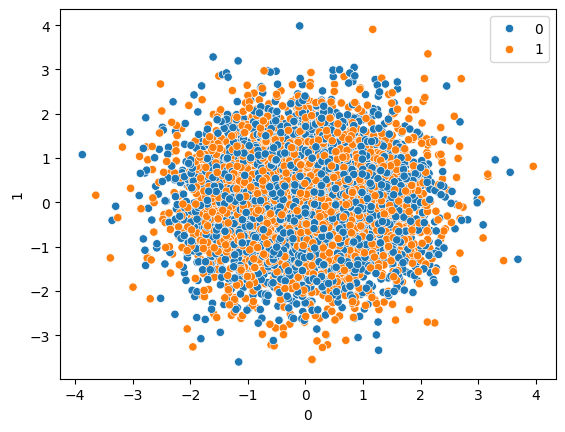

In [153]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [154]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.40,random_state=60)

In [155]:
from sklearn.svm import SVC

In [156]:
svc=SVC(kernel='linear')

In [157]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [158]:
y_pred=svc.predict(X_test)

In [159]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      2133
           1       0.88      0.87      0.88      2067

    accuracy                           0.88      4200
   macro avg       0.88      0.88      0.88      4200
weighted avg       0.88      0.88      0.88      4200

[[1893  240]
 [ 259 1808]]


## RBF Kernel

In [160]:
rbf=SVC(kernel='rbf')

In [161]:
rbf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [162]:
y_pred1=rbf.predict(X_test)

In [163]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      2133
           1       0.88      0.86      0.87      2067

    accuracy                           0.87      4200
   macro avg       0.87      0.87      0.87      4200
weighted avg       0.87      0.87      0.87      4200

[[1889  244]
 [ 296 1771]]


## Polynomial Kernel

In [164]:
poly=SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred2=poly.predict(X_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      2133
           1       0.87      0.85      0.86      2067

    accuracy                           0.87      4200
   macro avg       0.87      0.87      0.87      4200
weighted avg       0.87      0.87      0.87      4200

[[1879  254]
 [ 302 1765]]


## Sigmoid Kernel

In [165]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
y_pred3=sigmoid.predict(X_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      2133
           1       0.89      0.87      0.88      2067

    accuracy                           0.88      4200
   macro avg       0.88      0.88      0.88      4200
weighted avg       0.88      0.88      0.88      4200

[[1900  233]
 [ 273 1794]]


## Hyperparameter Tuning with SVC

In [166]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.511 total time=   0.2s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.511 total time=   0.3s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.509 total time=   0.2s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.509 total time=   0.3s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.509 total time=   0.2s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.891 total time=   0.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.852 total time=   0.1s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.1s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.877 total time=   0.1s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.861 total time=   0.1s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.893 total time=   0.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [167]:
print(grid.best_params_)

y_pred_grid = grid.predict(X_test)

print(classification_report(y_test, y_pred_grid))

{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      2133
           1       0.89      0.87      0.88      2067

    accuracy                           0.88      4200
   macro avg       0.88      0.88      0.88      4200
weighted avg       0.88      0.88      0.88      4200

